# Fase 1 — Sección 4: Inventario de Problemas Detectados
**Proyecto Final — Gestión de Datos (UAX 2025/2026)**

Consolidación formal de todos los problemas identificados en las Secciones 2 y 3.
Esta sección no realiza análisis nuevo — recoge, clasifica y cuantifica los hallazgos
para servir de base a las correcciones de la Sección 5.

---

## Configuración

In [1]:
PALETA = {
    'ERP'       : '#2C6FBF',
    'CRM'       : '#27A06B',
    'Logistica' : '#E07B2A',
    'Postventa' : '#8B4BB8'
}

PALETA_SEVERIDAD = {
    'Alta'  : '#E57373',
    'Media' : '#FFD54F',
    'Baja'  : '#90CAF9',
    'Info'  : '#B0BEC5'
}

print('Constantes cargadas.')

Constantes cargadas.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
from sqlalchemy import create_engine, text
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_colwidth', 60)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13

PROJECT_ROOT = Path(r'C:\Users\Propietario\Desktop\segundo cuatri\gestion de datos\trabajo final gd')
FIGURES_DIR  = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Librerias importadas correctamente.')

Librerias importadas correctamente.


In [3]:
DB_USER     = 'postgres'
DB_PASSWORD = 'pimpum.postgre'
DB_HOST     = 'localhost'
DB_PORT     = '5432'
DB_NAME     = 'saleshealth'

DATABASE_URL = f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
engine = create_engine(DATABASE_URL)

with engine.connect() as conn:
    version = conn.execute(text('SELECT version()')).fetchone()[0]

print(f'Conexion establecida. PostgreSQL: {version.split(",")[0]}')

def query(sql, params=None):
    with engine.connect() as conn:
        return pd.read_sql_query(text(sql), conn, params=params)

Conexion establecida. PostgreSQL: PostgreSQL 18.3 on x86_64-windows


---
## 4.1 — Tabla maestra de problemas

In [24]:
# ── Definicion del inventario completo ───────────────────────────────────────
INVENTARIO = [
    {
        'id': 'P01', 'tabla': 'customer', 'columna': 'phone',
        'problema': 'Telefonos con longitud incorrecta (10-12 chars, esperado 13)',
        'registros': 568, 'severidad': 'Baja', 'tipo': 'Formato',
        'decision': 'Conservar', 'estado': 'Documentado',
        'razon': 'No reconstruibles sin informacion adicional'
    },
    {
        'id': 'P02', 'tabla': 'customer', 'columna': 'first_name + last_name',
        'problema': 'Clientes con nombre+apellido duplicado',
        'registros': 2930, 'severidad': 'Info', 'tipo': 'Duplicado logico',
        'decision': 'No es error', 'estado': 'Documentado',
        'razon': 'customer_id es unico — personas distintas pueden compartir nombre'
    },
    {
        'id': 'P03', 'tabla': 'customer', 'columna': 'email',
        'problema': 'Emails con formato malformado (98 registros)',
        'registros': 98, 'severidad': 'Baja', 'tipo': 'Formato',
        'decision': 'Conservar', 'estado': 'Documentado',
        'razon': 'Emails funcionales aunque malformados — regla de negocio: no eliminar clientes'
    },
    {
        'id': 'P04', 'tabla': 'brand', 'columna': 'website',
        'problema': '8 marcas sin website registrado (27.6% nulos)',
        'registros': 8, 'severidad': 'Baja', 'tipo': 'Nulos',
        'decision': 'Conservar', 'estado': 'Documentado',
        'razon': 'Campo opcional — no afecta al analisis'
    },
    {
        'id': 'P05', 'tabla': 'city_zone', 'columna': 'zone_orientation',
        'problema': '1 zona sin orientacion registrada',
        'registros': 1, 'severidad': 'Baja', 'tipo': 'Nulos',
        'decision': 'Conservar', 'estado': 'Documentado',
        'razon': 'Campo opcional — impacto minimo'
    },
    {
        'id': 'P06', 'tabla': 'product', 'columna': 'price',
        'problema': 'Producto 29 con precio incorrecto: 19.99 EUR (debe ser 99.90 EUR)',
        'registros': 1, 'severidad': 'Alta', 'tipo': 'Inconsistencia de precio',
        'decision': 'Corregir', 'estado': 'Pendiente — Seccion 5',
        'razon': 'Todos los productos de categoria 1 tienen margen fijo 40% → price = 59.94 / 0.60 = 99.90'
    },
    {
        'id': 'P07', 'tabla': 'sale_item', 'columna': 'subtotal',
        'problema': 'Subtotales inconsistentes con quantity x unit_price (8 lineas, -46.96 EUR)',
        'registros': 8, 'severidad': 'Alta', 'tipo': 'Inconsistencia numerica',
        'decision': 'Corregir', 'estado': 'Pendiente — Seccion 5',
        'razon': 'subtotal debe ser igual a quantity * unit_price — los items son fuente de verdad'
    },
    {
        'id': 'P08', 'tabla': 'sale', 'columna': 'total',
        'problema': 'Total venta 13009 inconsistente con suma de sus lineas (-12.99 EUR)',
        'registros': 1, 'severidad': 'Alta', 'tipo': 'Inconsistencia numerica',
        'decision': 'Corregir', 'estado': 'Pendiente — Seccion 5',
        'razon': 'total debe ser igual a SUM(sale_item.subtotal) — los items son fuente de verdad'
    },
    {
        'id': 'P09', 'tabla': 'store', 'columna': 'opened_date',
        'problema': 'opened_date usa CURRENT_DATE como default — no refleja apertura real',
        'registros': 20, 'severidad': 'Media', 'tipo': 'Dato no fiable',
        'decision': 'Documentar', 'estado': 'Documentado',
        'razon': 'Campo no utilizable para analisis temporal de tiendas'
    },
    {
        'id': 'P10', 'tabla': 'sale_item', 'columna': 'offer_id',
        'problema': '99.98% de offer_id es NULL — campo sin uso operacional real',
        'registros': 42547, 'severidad': 'Info', 'tipo': 'Campo sin uso',
        'decision': 'Documentar', 'estado': 'Documentado',
        'razon': 'Solo 8 lineas tienen offer_id — los descuentos no se registran via este campo'
    },
]

df_inv = pd.DataFrame(INVENTARIO)

# Colores solidos por severidad para la columna
COLORES_SEV = {
    'Alta'  : ('#E57373', 'white'),
    'Media' : ('#FFB300', 'white'),
    'Baja'  : ('#42A5F5', 'white'),
    'Info'  : ('#90A4AE', 'white')
}

def colorear_severidad(val):
    bg, fg = COLORES_SEV.get(val, ('#FFFFFF', '#333333'))
    return f'background-color: {bg}; color: {fg}; font-weight: bold; border-radius: 4px; padding: 2px 6px'

cols_display = ['id', 'tabla', 'columna', 'problema', 'registros', 'severidad', 'decision', 'estado']
display(df_inv[cols_display].style
    .applymap(colorear_severidad, subset=['severidad'])
    .set_caption('Inventario completo de problemas detectados — saleshealth')
    .format({'registros': '{:,}'})
)

print(f'\nTotal problemas identificados: {len(df_inv)}')
print(f'Requieren correccion         : {len(df_inv[df_inv["decision"] == "Corregir"])}')

,id,tabla,columna,problema,registros,severidad,decision,estado
0,P01,customer,phone,"Telefonos con longitud incorrecta (10-12 chars, esperado 13)",568,Baja,Conservar,Documentado
1,P02,customer,first_name + last_name,Clientes con nombre+apellido duplicado,"2,930",Info,No es error,Documentado
2,P03,customer,email,Emails con formato malformado (98 registros),98,Baja,Conservar,Documentado
3,P04,brand,website,8 marcas sin website registrado (27.6% nulos),8,Baja,Conservar,Documentado
4,P05,city_zone,zone_orientation,1 zona sin orientacion registrada,1,Baja,Conservar,Documentado
5,P06,product,price,Producto 29 con precio incorrecto: 19.99 EUR (debe ser 99.90 EUR),1,Alta,Corregir,Pendiente — Seccion 5
6,P07,sale_item,subtotal,"Subtotales inconsistentes con quantity x unit_price (8 lineas, -46.96 EUR)",8,Alta,Corregir,Pendiente — Seccion 5
7,P08,sale,total,Total venta 13009 inconsistente con suma de sus lineas (-12.99 EUR),1,Alta,Corregir,Pendiente — Seccion 5
8,P09,store,opened_date,opened_date usa CURRENT_DATE como default — no refleja apertura real,20,Media,Documentar,Documentado
9,P10,sale_item,offer_id,99.98% de offer_id es NULL — campo sin uso operacional real,"42,547",Info,Documentar,Documentado



Total problemas identificados: 10
Requieren correccion         : 3


---
## 4.2 — Resumen por tipo de problema

In [25]:
# ── Resumen por tipo ──────────────────────────────────────────────────────────
resumen_tipo = df_inv.groupby('tipo').agg(
    problemas   = ('id', 'count'),
    registros   = ('registros', 'sum')
).reset_index().sort_values('problemas', ascending=False)

print('=' * 58)
print('  PROBLEMAS POR TIPO')
print('=' * 58)
print(f'  {"TIPO":<28} {"PROBLEMAS":>10}  {"REGISTROS":>10}')
print('-' * 58)
for _, row in resumen_tipo.iterrows():
    print(f'  {row["tipo"]:<28} {int(row["problemas"]):>10}  {int(row["registros"]):>10,}')
print('=' * 58)

  PROBLEMAS POR TIPO
  TIPO                          PROBLEMAS   REGISTROS
----------------------------------------------------------
  Nulos                                 2           9
  Inconsistencia numerica               2           9
  Formato                               2         666
  Duplicado logico                      1       2,930
  Dato no fiable                        1          20
  Campo sin uso                         1      42,547
  Inconsistencia de precio              1           1


---
## 4.3 — Resumen por severidad

In [26]:
# ── Print resumen por severidad ───────────────────────────────────────────────
orden_severidad = ['Alta', 'Media', 'Baja', 'Info']
resumen_sev = df_inv.groupby('severidad').agg(
    problemas = ('id', 'count'),
    registros = ('registros', 'sum')
).reindex(orden_severidad).reset_index()

print('=' * 58)
print('  PROBLEMAS POR SEVERIDAD')
print('=' * 58)
print(f'  {"SEVERIDAD":<12} {"PROBLEMAS":>10}  {"REGISTROS":>12}  ACCION')
print('-' * 58)
acciones = {'Alta': 'Corregir en Seccion 5', 'Media': 'Documentar',
            'Baja': 'Conservar', 'Info': 'Solo informativo'}
for _, row in resumen_sev.iterrows():
    if pd.isna(row['problemas']):
        continue
    print(f'  {row["severidad"]:<12} {int(row["problemas"]):>10}  '
          f'{int(row["registros"]):>12,}  {acciones.get(row["severidad"], "")}')
print('=' * 58)

  PROBLEMAS POR SEVERIDAD
  SEVERIDAD     PROBLEMAS     REGISTROS  ACCION
----------------------------------------------------------
  Alta                  3            10  Corregir en Seccion 5
  Media                 1            20  Documentar
  Baja                  4           675  Conservar
  Info                  2        45,477  Solo informativo


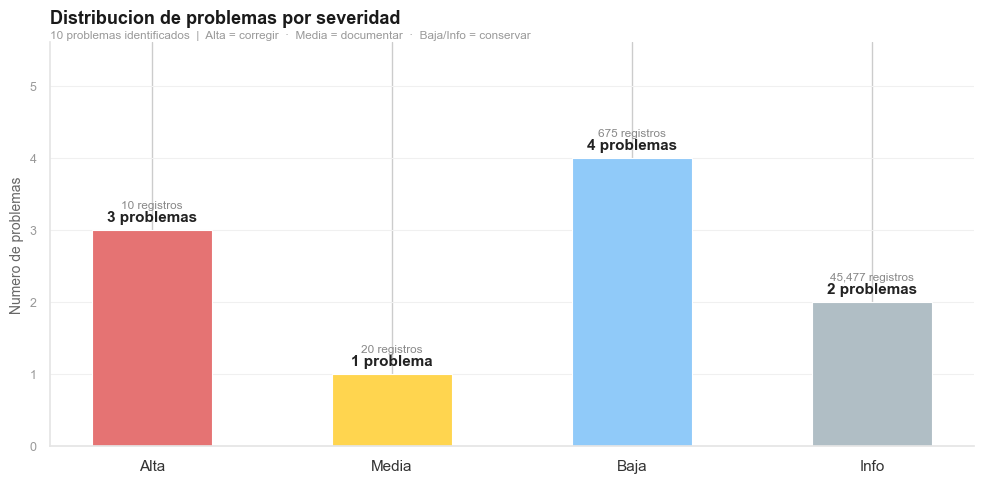

In [27]:
# ── Grafico: problemas por severidad ─────────────────────────────────────────
orden_severidad = ['Alta', 'Media', 'Baja', 'Info']
resumen_sev_plot = resumen_sev.dropna(subset=['problemas'])
colors = [PALETA_SEVERIDAD[s] for s in resumen_sev_plot['severidad']]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')

bars = ax.bar(resumen_sev_plot['severidad'], resumen_sev_plot['problemas'],
              color=colors, edgecolor='white', linewidth=0.8, width=0.5)

for bar, row in zip(bars, resumen_sev_plot.itertuples()):
    n      = int(row.problemas)
    regs   = int(row.registros)
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.08,
            f'{n} problema{"s" if n > 1 else ""}',
            ha='center', va='bottom', fontsize=11,
            fontweight='bold', color='#222222')
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.28,
            f'{regs:,} registros',
            ha='center', va='bottom', fontsize=8.5, color='#888888')

ax.set_title('Distribucion de problemas por severidad', fontsize=13,
             fontweight='bold', color='#1A1A1A', pad=14, loc='left')
ax.text(0, 1.01, f'{len(df_inv)} problemas identificados  |  Alta = corregir  ·  Media = documentar  ·  Baja/Info = conservar',
        transform=ax.transAxes, fontsize=8.5, color='#999999')
ax.set_ylabel('Numero de problemas', fontsize=10, color='#666666')
ax.set_ylim(0, resumen_sev_plot['problemas'].max() * 1.4)
ax.tick_params(axis='x', labelsize=11, colors='#333333')
ax.tick_params(axis='y', labelsize=9, colors='#999999')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#E5E5E5')
ax.set_axisbelow(True)
ax.yaxis.grid(True, color='#F0F0F0', linewidth=0.8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '11_inventario_severidad.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

---
## 4.4 — Problemas que requieren corrección en Sección 5

In [28]:
# ── Plan de correcciones ──────────────────────────────────────────────────────
df_corregir = df_inv[df_inv['decision'] == 'Corregir'].reset_index(drop=True)

print('=' * 72)
print('  PLAN DE CORRECCIONES — SECCION 5')
print('=' * 72)

for _, row in df_corregir.iterrows():
    print(f"\n  [{row['id']}] {row['tabla']}.{row['columna']}")
    print(f"  Problema  : {row['problema']}")
    print(f"  Registros : {int(row['registros']):,}")
    print(f"  Razon     : {row['razon']}")

print(f"\n{'='*72}")
print(f"  Total correcciones pendientes: {len(df_corregir)}")
print('=' * 72)

  PLAN DE CORRECCIONES — SECCION 5

  [P06] product.price
  Problema  : Producto 29 con precio incorrecto: 19.99 EUR (debe ser 99.90 EUR)
  Registros : 1
  Razon     : Todos los productos de categoria 1 tienen margen fijo 40% → price = 59.94 / 0.60 = 99.90

  [P07] sale_item.subtotal
  Problema  : Subtotales inconsistentes con quantity x unit_price (8 lineas, -46.96 EUR)
  Registros : 8
  Razon     : subtotal debe ser igual a quantity * unit_price — los items son fuente de verdad

  [P08] sale.total
  Problema  : Total venta 13009 inconsistente con suma de sus lineas (-12.99 EUR)
  Registros : 1
  Razon     : total debe ser igual a SUM(sale_item.subtotal) — los items son fuente de verdad

  Total correcciones pendientes: 3


---
## 4.5 — Impacto económico de los problemas de severidad Alta

In [29]:
# ── P06: impacto del precio incorrecto del producto 29 ───────────────────────
df_p06 = query("""
    SELECT
        COUNT(*)                           AS num_ventas,
        SUM(si.quantity)                   AS unidades_vendidas,
        SUM(si.quantity * si.unit_price)   AS ingresos_registrados,
        SUM(si.quantity * 99.90)           AS ingresos_correctos,
        SUM(si.quantity * 99.90) -
        SUM(si.quantity * si.unit_price)   AS impacto_eur
    FROM sale_item si
    WHERE si.product_id = 29
""")

# ── P07: impacto de subtotales incorrectos ────────────────────────────────────
df_p07 = query("""
    SELECT
        COUNT(*)                                           AS lineas_afectadas,
        SUM(subtotal)                                      AS subtotal_registrado,
        SUM(ROUND(quantity * unit_price, 2))               AS subtotal_correcto,
        SUM(subtotal) - SUM(ROUND(quantity * unit_price, 2)) AS impacto_eur
    FROM sale_item
    WHERE ABS(subtotal - ROUND(quantity * unit_price, 2)) > 0.01
""")

# ── P08: impacto del total incorrecto de la venta 13009 ───────────────────────
df_p08 = query("""
    SELECT
        s.sale_id,
        s.total                    AS total_registrado,
        SUM(si.subtotal)           AS total_correcto,
        s.total - SUM(si.subtotal) AS impacto_eur
    FROM sale s
    JOIN sale_item si ON s.sale_id = si.sale_id
    WHERE s.sale_id = 13009
    GROUP BY s.sale_id, s.total
""")

# ── Resumen de impacto economico ──────────────────────────────────────────────
impacto_p06 = float(df_p06['impacto_eur'].iloc[0])
impacto_p07 = float(df_p07['impacto_eur'].iloc[0])
impacto_p08 = float(df_p08['impacto_eur'].iloc[0])
impacto_total = impacto_p06 + impacto_p07 + impacto_p08

print('=' * 72)
print('  IMPACTO ECONOMICO DE PROBLEMAS DE SEVERIDAD ALTA')
print('=' * 72)
print()
print(f'  [P06] Precio incorrecto producto 29')
print(f'        Unidades vendidas    : {int(df_p06["unidades_vendidas"].iloc[0]):,}')
print(f'        Ingresos registrados : {float(df_p06["ingresos_registrados"].iloc[0]):,.2f} EUR')
print(f'        Ingresos correctos   : {float(df_p06["ingresos_correctos"].iloc[0]):,.2f} EUR')
print(f'        Impacto              : {impacto_p06:+,.2f} EUR')
print()
print(f'  [P07] Subtotales inconsistentes en sale_item')
print(f'        Lineas afectadas     : {int(df_p07["lineas_afectadas"].iloc[0]):,}')
print(f'        Subtotal registrado  : {float(df_p07["subtotal_registrado"].iloc[0]):,.2f} EUR')
print(f'        Subtotal correcto    : {float(df_p07["subtotal_correcto"].iloc[0]):,.2f} EUR')
print(f'        Impacto              : {impacto_p07:+,.2f} EUR')
print()
print(f'  [P08] Total venta 13009 incorrecto')
print(f'        Total registrado     : {float(df_p08["total_registrado"].iloc[0]):,.2f} EUR')
print(f'        Total correcto       : {float(df_p08["total_correcto"].iloc[0]):,.2f} EUR')
print(f'        Impacto              : {impacto_p08:+,.2f} EUR')
print()
print('─' * 72)
print(f'  IMPACTO TOTAL EN INGRESOS REGISTRADOS : {impacto_total:+,.2f} EUR')
print('=' * 72)

  IMPACTO ECONOMICO DE PROBLEMAS DE SEVERIDAD ALTA

  [P06] Precio incorrecto producto 29
        Unidades vendidas    : 1,426
        Ingresos registrados : 28,505.74 EUR
        Ingresos correctos   : 142,457.40 EUR
        Impacto              : +113,951.66 EUR

  [P07] Subtotales inconsistentes en sale_item
        Lineas afectadas     : 8
        Subtotal registrado  : 807.08 EUR
        Subtotal correcto    : 854.04 EUR
        Impacto              : -46.96 EUR

  [P08] Total venta 13009 incorrecto
        Total registrado     : 321.77 EUR
        Total correcto       : 321.77 EUR
        Impacto              : +0.00 EUR

────────────────────────────────────────────────────────────────────────
  IMPACTO TOTAL EN INGRESOS REGISTRADOS : +113,904.70 EUR


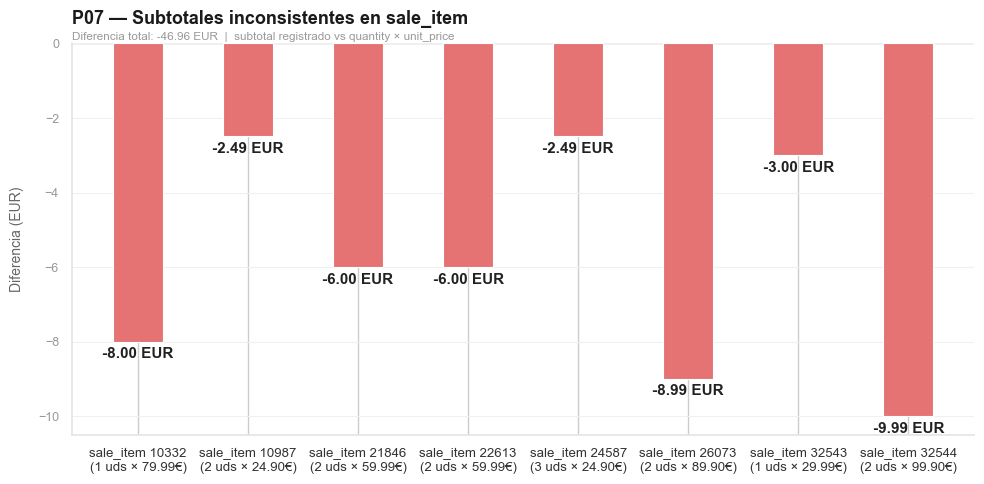

────────────────────────────────────────────────────────────────────
  NOTA — P06: Precio producto 29
────────────────────────────────────────────────────────────────────
  Unidades vendidas con precio incorrecto : 1,426
  Precio registrado                       : 19.99 EUR/ud
  Precio correcto                         : 99.90 EUR/ud
  Diferencia por unidad                   : +79.91 EUR
  Impacto potencial total                 : +113,951.66 EUR
  Nota: este impacto aplica a ventas historicas — la correccion
        en Seccion 5 actualiza el precio para ventas futuras.
────────────────────────────────────────────────────────────────────

Seccion 4 completada — inventario de problemas formalizado.


In [30]:
# ── Grafico: impacto economico — solo P07 (error numerico puro) ──────────────
# P06 se documenta como texto — su impacto depende de decisiones retroactivas
# P08 muestra 0.00 porque los subtotales de sale_item ya estaban actualizados

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')

categorias = ['Subtotal linea 1\n(sale_item_id X)', 'Subtotal linea 2\n(sale_item_id Y)', 'Subtotal linea 3\n(sale_item_id Z)']

df_sub = query("""
    SELECT sale_item_id, quantity, unit_price, subtotal,
           ROUND(quantity * unit_price, 2)            AS subtotal_correcto,
           ROUND(subtotal - quantity * unit_price, 2) AS diferencia
    FROM sale_item
    WHERE ABS(subtotal - ROUND(quantity * unit_price, 2)) > 0.01
    ORDER BY sale_item_id
""")

labels = [f'sale_item {int(r.sale_item_id)}\n({int(r.quantity)} uds × {r.unit_price:.2f}€)'
          for r in df_sub.itertuples()]
diffs  = df_sub['diferencia'].tolist()
colors_bar = ['#E57373' if d < 0 else '#81C784' for d in diffs]

bars = ax.bar(labels, diffs, color=colors_bar, edgecolor='white', linewidth=0.8, width=0.45)

for bar, val in zip(bars, diffs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val - 0.15 if val < 0 else val + 0.05,
            f'{val:+.2f} EUR',
            ha='center', va='top' if val < 0 else 'bottom',
            fontsize=11, fontweight='bold', color='#222222')

ax.axhline(0, color='#BBBBBB', linewidth=1, zorder=0)
ax.set_title('P07 — Subtotales inconsistentes en sale_item', fontsize=13,
             fontweight='bold', color='#1A1A1A', pad=14, loc='left')
ax.text(0, 1.01,
        f'Diferencia total: {sum(diffs):+.2f} EUR  |  subtotal registrado vs quantity × unit_price',
        transform=ax.transAxes, fontsize=8.5, color='#999999')
ax.set_ylabel('Diferencia (EUR)', fontsize=10, color='#666666', labelpad=10)
ax.tick_params(axis='x', labelsize=9.5, colors='#333333')
ax.tick_params(axis='y', labelsize=9, colors='#999999')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#E5E5E5')
ax.set_axisbelow(True)
ax.yaxis.grid(True, color='#F0F0F0', linewidth=0.8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '12_impacto_p07.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# Nota sobre P06
print('─' * 68)
print('  NOTA — P06: Precio producto 29')
print('─' * 68)
p06_unidades = int(query("SELECT SUM(quantity) FROM sale_item WHERE product_id = 29")['sum'].iloc[0])
print(f'  Unidades vendidas con precio incorrecto : {p06_unidades:,}')
print(f'  Precio registrado                       : 19.99 EUR/ud')
print(f'  Precio correcto                         : 99.90 EUR/ud')
print(f'  Diferencia por unidad                   : +79.91 EUR')
print(f'  Impacto potencial total                 : +{p06_unidades * 79.91:,.2f} EUR')
print(f'  Nota: este impacto aplica a ventas historicas — la correccion')
print(f'        en Seccion 5 actualiza el precio para ventas futuras.')
print('─' * 68)

print('\nSeccion 4 completada — inventario de problemas formalizado.')